## Corporate clustering prototype
This notebook analyses the `champions_group_data.csv` dataset. The goal is to build a prototype system that helps users derive actionable insights from company-level data by analysing firmographic, operational, and organizational attributes.

We will follow these steps:
1.  **Data Checking & Cleaning**: Load the data, check for missing values, and remove duplicates.
2.  **Exploratory Data Analysis (EDA)**: Investigate the features, their distributions, and their relationships with each other.
3.  **Preprocessing & Modeling**: Prepare the data for unsupervised modelling, using K-Means and Hierarchical Clustering to find natural groups.
4. **Cluster Interpretation**: Using Radar Charts to explain why a group exists.
5. **Building the tool**: Building a tool easily accesible for users to gain insights from big data.

## 1. Importing necessary package and getting data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors 

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.metrics import silhouette_score

import pickle
import warnings
warnings.filterwarnings('ignore') 

sns.set(style="whitegrid")

In [3]:
data = pd.read_csv('../data/champions_group_data.csv')

## 2. Data Checking & Cleaning

Before our data analysis, data checking and cleaning is a crucial step. We have to ensure that the data processed is cleaned such as no missing values and no duplicates.

### 2.1 Initial Check of Raw Dataset

In [4]:
# Check initial shape of dataset
data.shape

(8559, 72)

### 2.2 Cleaning of variables

In [51]:
# Checking if same standardisation 
data['Country'] = data['Country'].str.strip().str.title()

## 3. Exploratory Data Analysis

### 3.1 Univariate Analysis

To explore the variables on its own and examine its distribution and analyse its patterns. We will be doing this for selected variables. 

#### 3.1.1 Country

We will still keep the 'Country' variable even if it's skewed as it still provides valuable input. 

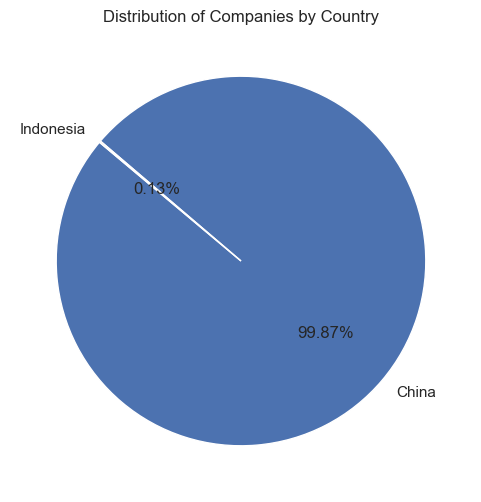

In [23]:
# Count how many companies are in each country
country_counts = data['Country'].value_counts()

# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(country_counts, labels=country_counts.index, autopct=lambda p: '{:.2f}%'.format(p), startangle=140)
plt.title('Distribution of Companies by Country')
plt.show()

#### 3.1.2 Entity Type

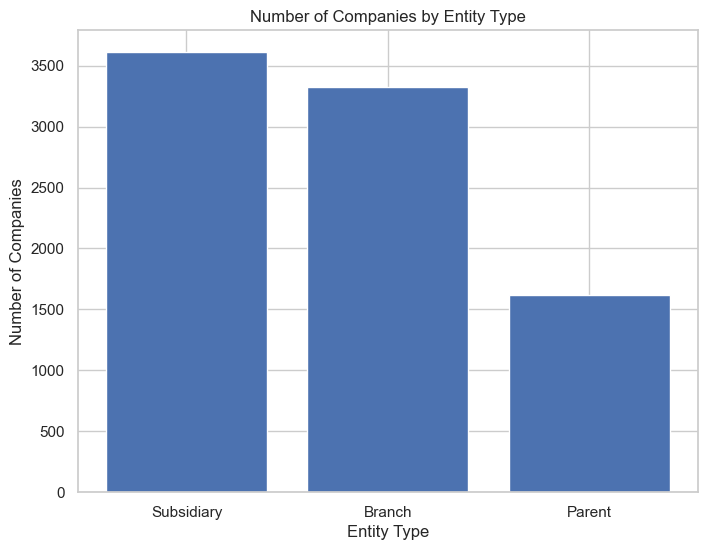

In [26]:
# Count how many companies are in each Entity Type
entity_counts = data['Entity Type'].value_counts()

plt.figure(figsize=(8,6))
plt.bar(entity_counts.index, entity_counts.values)
plt.xlabel('Entity Type')
plt.ylabel('Number of Companies')
plt.title('Number of Companies by Entity Type')
plt.show()

#### 3.1.3 Ownership Type

In [35]:
# Count how many companies are in each Ownership Type
ownership_counts = data['Ownership Type'].value_counts()

# Calculate percentage
ownership_percent = (ownership_counts / ownership_counts.sum()) * 100

# Combine into a table
ownership_table = pd.DataFrame({
    'Count': ownership_counts,
    'Percentage': ownership_percent.round(2)  # round to 2 decimals
})

# Sort by count descending
ownership_table = ownership_table.sort_values(by='Count', ascending=False)

ownership_table


,Count,Percentage
Ownership Type,,
Private,7457,99.73
Nonprofit,8,0.11
Partnership,7,0.09
Public Sector,4,0.05
Non-Corporates,1,0.01


#### 3.1.4 Industry Codes

We use visualizations to determine the most suitable industry code. Industry codes classify companies into sectors, enabling meaningful grouping for analysis and benchmarking. We select the code with the highest data coverage to ensure consistency and completeness in our segmentation.

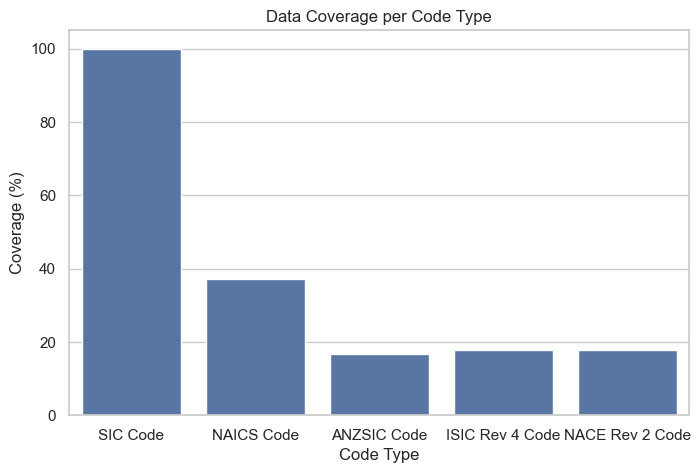

In [40]:
code_columns = [
    'SIC Code',
    'NAICS Code',
    'ANZSIC Code',
    'ISIC Rev 4 Code',
    'NACE Rev 2 Code'
]

coverage = (1 - data[code_columns].isna().mean()) * 100  # % of non-missing
plt.figure(figsize=(8,5))
sns.barplot(x=coverage.index, y=coverage.values)
plt.ylabel('Coverage (%)')
plt.xlabel('Code Type')
plt.title('Data Coverage per Code Type')
# plt.xticks(rotation=45)
plt.show()


Since SIC Code is 100% populated in the dataset, we will use this instead of the other codes.

#### 3.1.4 Year Found

In [47]:
bins = list(range(1900, 2030, 10))  # 1900, 1910, ..., 2020
labels = [f"{bins[i]}-{bins[i+1]-1}" for i in range(len(bins)-1)]

# Creating bins for Year
data['Year_Range'] = pd.cut(data['Year Found'], bins=bins, labels=labels, right=False)
bin_counts = data['Year_Range'].value_counts().sort_index()

# Calculate percentages
bin_percent = (bin_counts / bin_counts.sum()) * 100

# Combine into a table
year_table = pd.DataFrame({
    'Count': bin_counts,
    'Percentage': bin_percent.round(2)
})

year_table

,Count,Percentage
Year_Range,,
1900-1909,1,0.02
1910-1919,0,0.00
1920-1929,0,0.00
1930-1939,0,0.00
1940-1949,2,0.05
1950-1959,23,0.56
1960-1969,7,0.17
1970-1979,10,0.25
1980-1989,126,3.09


#### 3.1.5 Is Headquarters

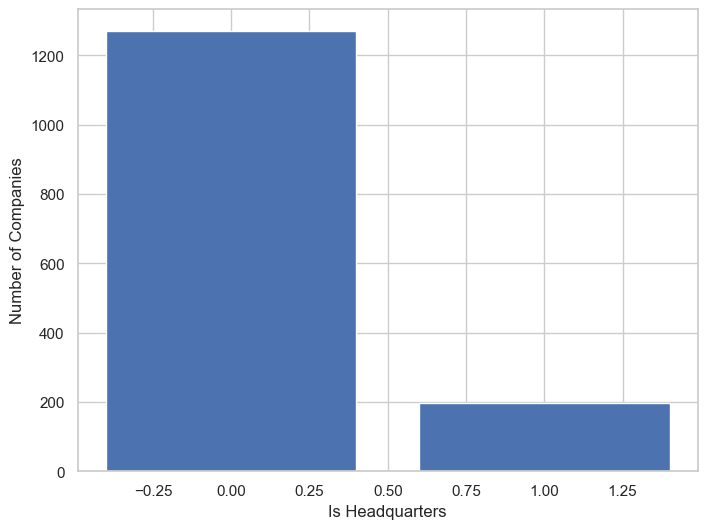

In [50]:
# Count how many companies are in each category
headquarter_counts = data['Is Headquarters'].value_counts()

plt.figure(figsize=(8,6))
plt.bar(headquarter_counts.index, headquarter_counts.values)
plt.xlabel('Is Headquarters')
plt.ylabel('Number of Companies')
plt.show()

### 3.2 Bivariate Analysis

This explores relationships between 2 variables. We will explore variables that are likely to be related to each other.  

### 3.2.1 IT Spend & IT Budget